# 2 · Two coupled species on a moving membrane (§1.4.5)

This is the project's first concrete goal: a 2-D cell whose membrane carries an
**active** and an **inactive** receptor species. They interconvert by mass action
(`k_on·inactive − k_off·active`), both diffuse, and the membrane **expands
radially** — so each species is diluted by the stretch.

It runs end-to-end through the formalism as **one coupled solve**. Three physical
properties fall out:

- the membrane motion drives an **automatic dilution** term (you can't forget it);
- total `active + inactive` is **conserved** (the reaction conserves the sum,
  dilution conserves each species' integral);
- `k_on > k_off` shifts mass **inactive → active**.

Note there is no "reaction" object anywhere — a reaction is just an algebraic
`source:` string; the coupling is a *solver* concern.

In [1]:
from pathlib import Path
from vcell_fenics.formalism import load_yaml, validate
from vcell_fenics.backend import assemble, make_disk_membrane_geometry
from dolfinx import fem
from mpi4py import MPI
import matplotlib.pyplot as plt

## The model

This is the committed reference fixture `tests/fixtures/section_1_4_5.yaml`. Note
the two equations sharing the `membrane` subdomain, each with a `source` that
references the *other* species, and the prescribed radial `velocity`.

In [2]:
md = load_yaml(Path("../../tests/fixtures/section_1_4_5.yaml"))
print("validation errors:", [d for d in validate(md) if d.severity == "error"] or "none")
for eq in md.equations:
    print(f"  {eq.variable:13s} source = {eq.terms.get('source')!r}")

validation errors: none
  rho_active    source = 'k_on * rho_inactive - k_off * rho_active'
  rho_inactive  source = '-k_on * rho_inactive + k_off * rho_active'


In [3]:
geometry = make_disk_membrane_geometry("disk_radius_1", surface_subdomain="membrane", radius=1.0, h=0.1)
dp = assemble(md, geometry, dt=0.01)
print("term kinds:", sorted(t.name for t in dp.term_kinds()))
print("coupled solve over", dp.V.num_sub_spaces, "components")

term kinds: ['DIFFUSION', 'DILUTION', 'SOURCE', 'TIME_DERIVATIVE']
coupled solve over 2 components


## Step in time, track each species' mass

`unknown.sub(0)` is the active species, `sub(1)` the inactive. We integrate each
over the (moving) membrane at every step.

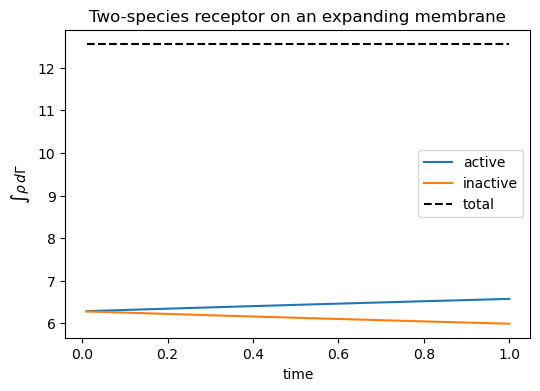

total: 12.565109 -> 12.565109   relative drift 8.2e-15
active/inactive: 1.00 -> 1.10   (-> k_on/k_off = 2.0)


In [4]:
def species_mass(k):
    local = fem.assemble_scalar(fem.form(dp.unknown.sub(k) * dp.dx))
    return float(dp.V.mesh.comm.allreduce(local, op=MPI.SUM))

t, active, inactive = [], [], []
for i in range(100):  # ṙ = 1, T = 1  ⇒  membrane radius 1 → 2
    dp.step()
    t.append((i + 1) * 0.01); active.append(species_mass(0)); inactive.append(species_mass(1))
total = [a + i for a, i in zip(active, inactive)]

plt.figure(figsize=(6, 4))
plt.plot(t, active, label="active")
plt.plot(t, inactive, label="inactive")
plt.plot(t, total, "k--", label="total")
plt.xlabel("time"); plt.ylabel(r"$\int \rho\,d\Gamma$"); plt.legend()
plt.title("Two-species receptor on an expanding membrane")
plt.show()
drift = (total[-1] - total[0]) / total[0]
print(f"total: {total[0]:.6f} -> {total[-1]:.6f}   relative drift {drift:.1e}")
print(f"active/inactive: {active[0]/inactive[0]:.2f} -> {active[-1]/inactive[-1]:.2f}   (-> k_on/k_off = 2.0)")

**Takeaway.** Total receptor mass is conserved across a 2× membrane expansion
while the species ratio relaxes toward the kinetic equilibrium `k_on/k_off = 2`.
The printed relative drift is the round-off of the conservative ALE time term
(`tests/test_backend_dilution.py` gates the same expansion at 1e-11); an earlier
snapshot of this notebook, before that time term, showed 0.4 % drift and called it
"conserved". The dilution term that makes conservation hold was added automatically
because the subdomain moves — the single most common moving-membrane bug, designed out.
